In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("creditcard.csv")

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# This is a structured, tabular dataset used for supervised binary classification, with highly imbalanced classes and PCA-transformed numerical features.
# The dataset is highly imbalanced because fraudulent transactions are naturally rare compared to normal transactions. This reflects real-world scenarios, where detecting rare but costly events is the main challenge.

# PCA was applied primarily for anonymization to protect sensitive financial data, while also reducing dimensionality and removing feature correlation, making the dataset suitable for modeling without exposing original variables.
# PCA anonymizes data by transforming original features into new components that are linear combinations of all variables, removing direct interpretability and making it difficult to reconstruct sensitive information while preserving underlying patterns.

In [10]:
print(f"Number of Rows:{df.shape[0]}")
print(f"Number of Columns:{df.shape[1]}")

Number of Rows:284807
Number of Columns:31


In [11]:
print("The name of the columns are : ")
df.columns

The name of the columns are : 


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [12]:
df.drop(['Time'],axis=1,inplace=True)

In [13]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
df.dtypes

V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [15]:
df.isna().sum()

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [16]:
df_fraud = df[df['Class'] == 1]
df_true = df[df['Class'] == 0]

df_true = df_true.sample(frac=0.5)

data = pd.concat([df_true, df_fraud])
data = data.reset_index(drop=True)

data.shape


(142650, 30)

In [17]:
data['Amount'].describe()

count    142650.000000
mean         87.683417
std         246.203932
min           0.000000
25%           5.490000
50%          22.000000
75%          77.867500
max       25691.160000
Name: Amount, dtype: float64

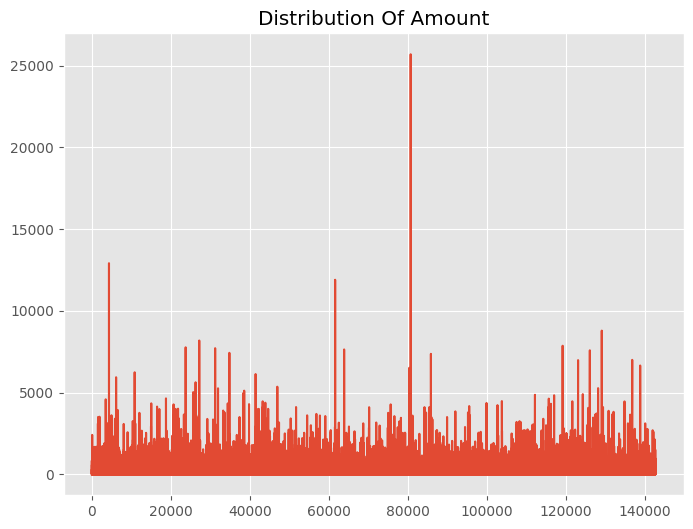

In [18]:
with plt.style.context(('ggplot')):
    plt.figure(figsize=(8,6))
    plt.title("Distribution Of Amount")
    plt.plot(data['Amount'])
    plt.show()


 # Initial visualization using a line plot to observe how transaction amounts vary across records.
# However, this does not represent the true distribution since the x-axis reflects index, not value frequency.

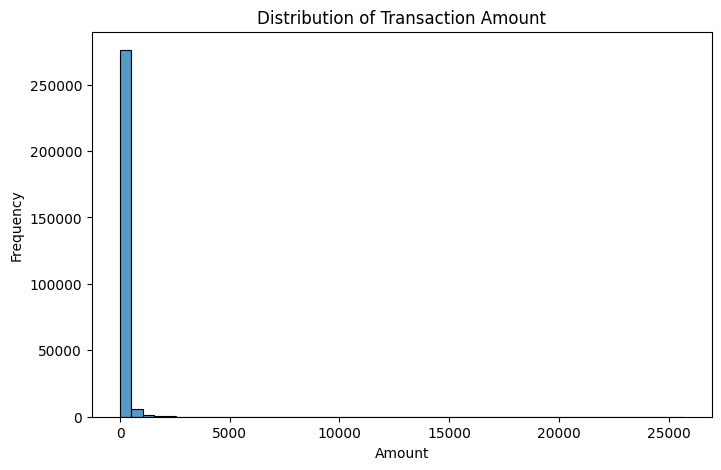

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

# Histogram used to analyze the distribution of transaction amounts.
# The plot shows a highly right-skewed distribution, where most transactions are of low value,
# with a few high-value outliers forming a long tail.

# A histogram is used to properly visualize the distribution of transaction amounts.
# The data is heavily right-skewed, indicating that the majority of transactions are small,
# while a small number of high-value transactions act as outliers.
# This suggests the need for scaling or transformation before modeling.

In [24]:
#percnetage of Fraud Transactions
fraud_per=round(len(df[df['Class'] == 1])/len(df[df['Class'] == 0])*100,4)

In [25]:
print(f"The percentage of Fraud Transaction using Credit Card:{fraud_per}")

The percentage of Fraud Transaction using Credit Card:0.173


In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
sc = StandardScaler()
data["Amount"] = sc.fit_transform(data[["Amount"]])

In [28]:
df['Amount']

0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64

In [29]:
data.drop_duplicates(inplace=True)

In [30]:
data.shape

(139685, 30)

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
import numpy as np

# Remove inf and NaN
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

In [33]:

X = data.drop("Class", axis=1)
y = data["Class"]

y = y.values.ravel()

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#ravel() is used to convert a multi-dimensional array into a 1D array, which is required by most machine learning models for the target variable.

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
LR = LogisticRegression(max_iter=1000, solver='liblinear')

LR.fit(x_train, y_train)

y_pred = LR.predict(x_test)

print(f"Accuracy: {round(LR.score(x_test, y_test)*100,2)}")

Accuracy: 99.87


In [80]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,precision_score,recall_score,accuracy_score

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nPrecision:", precision_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred))

# F1 Score (focus on fraud = class 1)
print("\nF1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[27840     7]
 [   29    61]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27847
           1       0.90      0.68      0.77        90

    accuracy                           1.00     27937
   macro avg       0.95      0.84      0.89     27937
weighted avg       1.00      1.00      1.00     27937


Precision: 0.8970588235294118

Recall: 0.6777777777777778

F1 Score: 0.7721518987341772


# Due to class imbalance, accuracy is not a reliable metric. F1 score is used to evaluate the model’s ability to correctly identify fraud cases while balancing precision and recall.

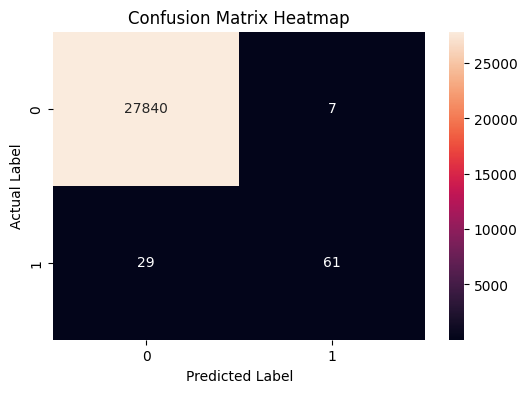

In [38]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
RF=RandomForestClassifier()
RF.fit(x_train,y_train)
y_rf=RF.predict(x_test)
print(f"Accuracy: {round(RF.score(x_test, y_test)*100,2)}")

Accuracy: 99.93


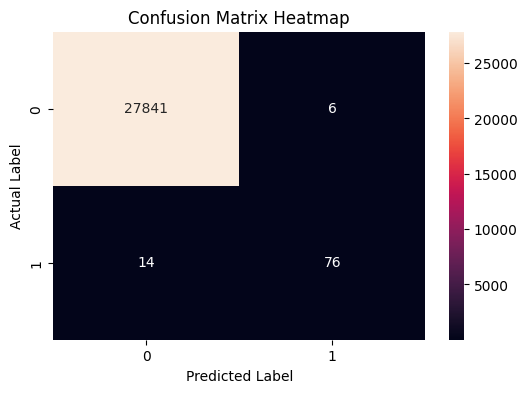

In [41]:
# Compute confusion matrix
cm1 = confusion_matrix(y_test, y_rf)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm1, annot=True, fmt='d')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [42]:
print("\nClassification Report:")
print(classification_report(y_test, y_rf))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27847
           1       0.93      0.84      0.88        90

    accuracy                           1.00     27937
   macro avg       0.96      0.92      0.94     27937
weighted avg       1.00      1.00      1.00     27937



In [43]:
print("\nPrecision:", precision_score(y_test, y_rf))


Precision: 0.926829268292683


In [54]:
print("\nRecall:", recall_score(y_test, y_rf))


Recall: 0.8444444444444444


In [56]:
print("\nF1 Score:", f1_score(y_test, y_rf))


F1 Score: 0.8837209302325582


In [58]:
from sklearn.tree import DecisionTreeClassifier

In [60]:
dt=DecisionTreeClassifier()

In [62]:
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [64]:
y_dt=dt.predict(x_test)

In [66]:
print(f"Accuracy: {round(RF.score(x_test, y_test)*100,2)}")

Accuracy: 99.93


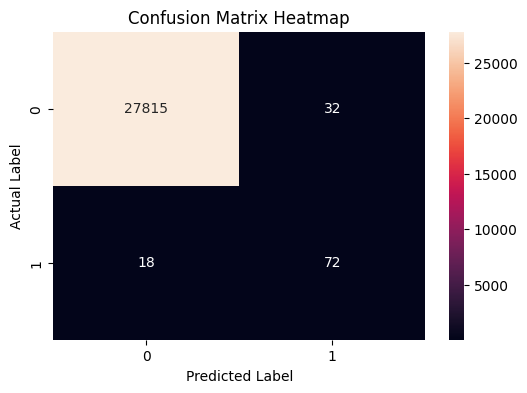

In [68]:
# Compute confusion matrix
cm1 = confusion_matrix(y_test, y_dt)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm1, annot=True, fmt='d')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [70]:
print("\nClassification Report:")
print(classification_report(y_test, y_dt))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27847
           1       0.69      0.80      0.74        90

    accuracy                           1.00     27937
   macro avg       0.85      0.90      0.87     27937
weighted avg       1.00      1.00      1.00     27937



In [72]:
print("\nPrecision:", precision_score(y_test, y_dt))


Precision: 0.6923076923076923


In [74]:
print("\nRecall:", recall_score(y_test, y_dt))


Recall: 0.8


In [76]:
print("\nF1 Score:", f1_score(y_test, y_dt))


F1 Score: 0.7422680412371134


In [82]:
final_data = pd.DataFrame({
    'Models': ['LR', 'RF', 'DT'],
    
    'Accuracy': [
        round(accuracy_score(y_test, y_pred)*100, 2),
        round(accuracy_score(y_test, y_rf)*100, 2),
        round(accuracy_score(y_test, y_dt)*100, 2)
    ],
    
    'Precision': [
        round(precision_score(y_test, y_pred)*100, 2),
        round(precision_score(y_test, y_rf)*100, 2),
        round(precision_score(y_test, y_dt)*100, 2)
    ],
    
    'Recall': [
        round(recall_score(y_test, y_pred)*100, 2),
        round(recall_score(y_test, y_rf)*100, 2),
        round(recall_score(y_test, y_dt)*100, 2)
    ],
    
    'F1': [
        round(f1_score(y_test, y_pred)*100, 2),
        round(f1_score(y_test, y_rf)*100, 2),
        round(f1_score(y_test, y_dt)*100, 2)
    ]
})

In [84]:
final_data

,Models,Accuracy,Precision,Recall,F1
0,LR,99.87,89.71,67.78,77.22
1,RF,99.93,92.68,84.44,88.37
2,DT,99.82,69.23,80.00,74.23


C:\Users\sayan\AppData\Local\Temp\ipykernel_7324\3600525694.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


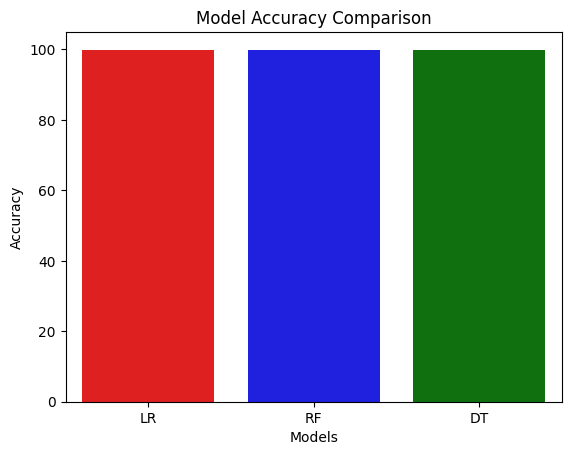

In [86]:
sns.barplot(
    x='Models',
    y='Accuracy',
    data=final_data,
    palette=['red', 'blue', 'green']
)

plt.title("Model Accuracy Comparison")
plt.show()

In [88]:
df.duplicated().any()

True

In [90]:
df1=df.drop_duplicates()

In [92]:
df1.shape

(275663, 30)

In [94]:
X=df1.drop('Class',axis=1)
y=df1['Class']

In [96]:
X.shape

(275663, 29)

In [98]:
y.shape

(275663,)

In [100]:
import sklearn
import imblearn

print(sklearn.__version__)
print(imblearn.__version__)

1.3.2
0.11.0


In [102]:
from imblearn.over_sampling import SMOTE

In [104]:
smote=SMOTE(random_state=42)

In [106]:
X_res,y_res=smote.fit_resample(X,y)

In [108]:
y_res.value_counts()

Class
0    275190
1    275190
Name: count, dtype: int64

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [120]:
print(X_train.shape)
print(y_train.shape)

(440304, 29)
(440304,)


In [122]:
LR1 = LogisticRegression(max_iter=1000, class_weight='balanced')

In [124]:
LR1.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [130]:
y_pred1=LR1.predict(X_test)

In [132]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96     55073
           1       0.98      0.94      0.96     55003

    accuracy                           0.96    110076
   macro avg       0.96      0.96      0.96    110076
weighted avg       0.96      0.96      0.96    110076



In [144]:
print("\naccuracy score:", accuracy_score(y_test, y_pred1))


accuracy score: 0.9588920382281333


In [146]:
print("\nPrecision:", precision_score(y_test, y_pred1))


Precision: 0.9815132783882784


In [148]:
print("\nRecall:", recall_score(y_test, y_pred1))


Recall: 0.9353489809646747


In [150]:
print("\nF1 Score:", f1_score(y_test, y_pred1))


F1 Score: 0.9578752362245041


In [152]:
RF1=RandomForestClassifier()

In [154]:
RF1.fit(X_train,y_train)

RandomForestClassifier()

In [156]:
y_rf1=RF1.predict(X_test)

In [158]:
print(classification_report(y_test, y_rf1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55073
           1       1.00      1.00      1.00     55003

    accuracy                           1.00    110076
   macro avg       1.00      1.00      1.00    110076
weighted avg       1.00      1.00      1.00    110076



In [160]:
print("\naccuracy score:", accuracy_score(y_test, y_rf1))


accuracy score: 0.9998909844107707


In [162]:
print("\nPrecision:", precision_score(y_test, y_rf1))


Precision: 0.9997818776697265


In [164]:
print("\nRecall:", recall_score(y_test, y_rf1))


Recall: 1.0


In [166]:
print("\nF1 Score:", f1_score(y_test, y_rf1))


F1 Score: 0.9998909269392281


In [168]:
dt1=DecisionTreeClassifier()

In [170]:
dt1.fit(X_train,y_train)

DecisionTreeClassifier()

In [172]:
y_dt1=dt1.predict(X_test)

In [174]:
print(classification_report(y_test, y_dt1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55073
           1       1.00      1.00      1.00     55003

    accuracy                           1.00    110076
   macro avg       1.00      1.00      1.00    110076
weighted avg       1.00      1.00      1.00    110076



In [176]:
print("\naccuracy score:", accuracy_score(y_test, y_dt1))


accuracy score: 0.9982194120425888


In [182]:
print("\nPrecision score:", precision_score(y_test, y_dt1))


Precision score: 0.9974405053640473


In [184]:
print("\nRecall score:", recall_score(y_test, y_dt1))


Recall score: 0.9990000545424795


In [186]:
print("\nF1 score:", f1_score(y_test, y_dt1))


F1 score: 0.9982196708207682


In [190]:
final_data1 = pd.DataFrame({
    'Models': ['LR1', 'RF1', 'DT1'],
    
    'Accuracy': [
        round(accuracy_score(y_test, y_pred1)*100, 2),
        round(accuracy_score(y_test, y_rf1)*100, 2),
        round(accuracy_score(y_test, y_dt1)*100, 2)
    ],
    
    'Precision': [
        round(precision_score(y_test, y_pred1)*100, 2),
        round(precision_score(y_test, y_rf1)*100, 2),
        round(precision_score(y_test, y_dt1)*100, 2)
    ],
    
    'Recall': [
        round(recall_score(y_test, y_pred1)*100, 2),
        round(recall_score(y_test, y_rf1)*100, 2),
        round(recall_score(y_test, y_dt1)*100, 2)
    ],
    
    'F1': [
        round(f1_score(y_test, y_pred1)*100, 2),
        round(f1_score(y_test, y_rf1)*100, 2),
        round(f1_score(y_test, y_dt1)*100, 2)
    ]
})

In [194]:
final_data1

,Models,Accuracy,Precision,Recall,F1
0,LR1,95.89,98.15,93.53,95.79
1,RF1,99.99,99.98,100.00,99.99
2,DT1,99.82,99.74,99.90,99.82


# Save the model

In [199]:
rf1=RandomForestClassifier()
rf1.fit(X_res,y_res)

RandomForestClassifier()

In [200]:
import joblib

joblib.dump(rf1, "credit_model.pkl")

['credit_model.pkl']

In [203]:
model=joblib.load("credit_model.pkl")

In [211]:
pred=model.predict([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]])

C:\Users\sayan\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [213]:
if pred==0:
    print("Normal Transaction")
else:
    print("Fradulent Transaction")

Normal Transaction


In [215]:
from tkinter import *
import joblib
import numpy as np

# Load model
model = joblib.load("credit_model.pkl")

def predict():
    try:
        values = [float(entry.get()) for entry in entries]
        data = np.array(values).reshape(1, -1)

        pred = model.predict(data)[0]

        if pred == 0:
            result_label.config(text="Normal Transaction", fg="green")
        else:
            result_label.config(text="Fraud Transaction", fg="red")

    except:
        result_label.config(text="Invalid Input", fg="orange")

# GUI
root = Tk()
root.title("Credit Card Fraud Detection")

entries = []

# Create 29 inputs
for i in range(29):
    Label(root, text=f"V{i+1}").grid(row=i, column=0)
    e = Entry(root)
    e.grid(row=i, column=1)
    entries.append(e)

Button(root, text="Predict", command=predict).grid(row=30, column=0, columnspan=2)

result_label = Label(root, text="", font=("Arial", 12))
result_label.grid(row=31, column=0, columnspan=2)

root.mainloop()

C:\Users\sayan\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
